In [74]:
# pip install statsmodels


In [77]:
# Import dependencies
import gc
import pandas as pd
from datetime import datetime, timedelta
import numpy as np
import seaborn as sns
import plotly.express as px

import matplotlib.pyplot as plt
import squarify
import matplotlib.cm as cm
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go
from statsmodels.graphics.mosaicplot import mosaic

In [2]:
# Display settings for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)  # Display only the first 10 rows in output

In [3]:
# df_leads = None  # Clear the DataFrame
# df_opps = None  # Clear the DataFrame
# df_leads2 = None  # Clear the DataFrame
# df_leads2 = None  # Clear the DataFrame
# import gc
# gc.collect()  # Force garbage collection to remove old references

In [4]:
# Load the Salesforce report exports from Excel files
Leads_df = pd.read_excel('SFLeadsAllBUs.xlsx')  

In [5]:
#print(Leads_df.head())

In [6]:
# plt.close('all')  # This closes all active figures to clear the plotting cache

In [7]:
# Displaying column names of all dataframes
print(Leads_df.columns)

Index(['LeadStatus', 'CompanyName', 'LeadRecordType', 'LeadSource',
       'CreatedDate', 'CreatedBy', 'ConvertedLead', 'LastModifiedDate',
       'Rating', 'Campaigns', 'LeadOwner'],
      dtype='object')


In [8]:
# Ensure date columns are in datetime format
Leads_df['CreatedDate'] = pd.to_datetime(Leads_df['CreatedDate'])
Leads_df['LastModifiedDate'] = pd.to_datetime(Leads_df['LastModifiedDate'])

In [ ]:
# Ensure blanks and nulls are included in the count and sort in descending order
record_type_counts = Leads_df['LeadRecordType'].value_counts(dropna=False).sort_values(ascending=True)

# Creating a horizontal bar chart with the sorted data
plt.figure(figsize=(12, 4))
record_type_counts.plot(kind='barh')

# Adding labels and title
plt.xlabel('Number of Leads')
plt.ylabel('Lead Record Type')
plt.title('Number of Leads by Lead Record Type')

# Adding the total lead count at the end of each bar
for index, value in enumerate(record_type_counts):
    plt.text(value, index, str(value), va='center')

plt.show()

In [ ]:
# creating a horizontal bar chart for the number of leads in descending order by Lead Source and adding total leads count at the end of each bar
# including blanks and nulls

# Ensure blanks and nulls are included in the count
lead_counts = Leads_df['LeadSource'].value_counts(dropna=False).sort_values(ascending=True)

# Creating a horizontal bar chart with the sorted data
plt.figure(figsize=(12, 6))
lead_counts.plot(kind='barh')

# Adding labels and title
plt.xlabel('Number of Leads')
plt.ylabel('Lead Source')
plt.title('Number of Leads by Lead Source')

# Adding the total lead count at the end of each bar
for index, value in enumerate(lead_counts):
    plt.text(value, index, str(value), va='center')

plt.show()

In [ ]:
# Replace NaN values with '' (empty string) for both LeadRecordType and LeadSource
Leads_df['LeadRecordType'] = Leads_df['LeadRecordType'].fillna('blank')
Leads_df['LeadSource'] = Leads_df['LeadSource'].fillna('blank')

# Create a pivot table to get the count of LeadRecordType by LeadSource
lead_source_record_type = Leads_df.pivot_table(index='LeadSource', columns='LeadRecordType', aggfunc='size', fill_value=0)

# Sort the pivot table by the total number of leads per LeadSource in descending order
lead_source_record_type = lead_source_record_type.loc[lead_source_record_type.sum(axis=1).sort_values(ascending=True).index]

# Creating a horizontal stacked bar chart
plt.figure(figsize=(12, 8))
lead_source_record_type.plot(kind='barh', stacked=True, figsize=(18, 6))

# Adding labels and title
plt.xlabel('Number of Leads')
plt.ylabel('Lead Source')
plt.title('Number of Leads by Lead Source and Lead Record Type')

plt.legend(title='Lead Record Type', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()  # To ensure the labels and title fit nicely
plt.show()


In [ ]:
# Total Leads by Rating in a horizontal bar chart
# Ensure blanks and nulls are included in the count

lead_rating_counts = Leads_df['Rating'].value_counts(dropna=False).sort_values(ascending=True)

# Creating a horizontal bar chart with the sorted data
plt.figure(figsize=(14, 6))
lead_rating_counts.plot(kind='barh')

# Adding labels and title
plt.xlabel('Number of Leads')
plt.ylabel('Lead Rating')
plt.title('Number of Leads by Lead Rating (All Company)')

# Adding the total lead count at the end of each bar
for index, value in enumerate(lead_rating_counts):
    plt.text(value, index, str(value), va='center')

plt.show()

In [ ]:
# Total number of leads by Rating and by LeadRecordType, including blanks and nulls
# Replace NaN values with '' (empty string) for both Rating and LeadRecordType
Leads_df['Rating'] = Leads_df['Rating'].fillna('blank')
Leads_df['LeadRecordType'] = Leads_df['LeadRecordType'].fillna('blank')

# Create a pivot table to get the count of Rating by LeadRecordType
rating_record_type = Leads_df.pivot_table(index='Rating', columns='LeadRecordType', aggfunc='size', fill_value=0)

# Sort the pivot table by the total number of leads per Rating in descending order
rating_record_type = rating_record_type.loc[rating_record_type.sum(axis=1).sort_values(ascending=True).index]

# Creating a horizontal stacked bar chart
plt.figure(figsize=(12, 8))
rating_record_type.plot(kind='barh', stacked=True, figsize=(18, 6))

# Adding labels and title
plt.xlabel('Number of Leads')
plt.ylabel('Lead Rating')
plt.title('Number of Leads by Lead Rating and Lead Record Type')

plt.legend(title='Lead Record Type', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()  # To ensure the labels and title fit nicely
plt.show()

In [ ]:
# give Rating and Number of Leads for Lead Record Type: Canada Internal Leads
# Ensure blanks and nulls are included in the count
canada_internal_leads = Leads_df[Leads_df['LeadRecordType'] == 'Canada Internal Leads']
rating_counts = canada_internal_leads['Rating'].value_counts(dropna=False).sort_values(ascending=True)

# Creating a horizontal bar chart with the sorted data
plt.figure(figsize=(12, 4))
rating_counts.plot(kind='barh')

# Adding labels and title
plt.xlabel('Number of Leads')
plt.ylabel('Lead Rating')
plt.title('Number of Leads by Lead Rating for Canada Internal Leads')

# Adding the total lead count at the end of each bar
for index, value in enumerate(rating_counts):
    plt.text(value, index, str(value), va='center')

plt.show()

In [ ]:
# give Rating and Number of Leads for Lead Record Type: US Internal Leads
# Ensure blanks and nulls are included in the count
us_internal_leads = Leads_df[Leads_df['LeadRecordType'] == 'US Internal Leads']
rating_counts = us_internal_leads['Rating'].value_counts(dropna=False).sort_values(ascending=True)

# Creating a horizontal bar chart with the sorted data
plt.figure(figsize=(12, 4))
rating_counts.plot(kind='barh')

# Adding labels and title
plt.xlabel('Number of Leads')
plt.ylabel('Lead Rating')
plt.title('Number of Leads by Lead Rating for US Internal Leads')

# Adding the total lead count at the end of each bar
for index, value in enumerate(rating_counts):
    plt.text(value, index, str(value), va='center')

plt.show()

In [ ]:
# give Rating and Number of Leads for Lead Record Type: Company2
# Ensure blanks and nulls are included in the count
Company2_leads = Leads_df[Leads_df['LeadRecordType'] == 'Company2']
rating_counts = Company2_leads['Rating'].value_counts(dropna=False).sort_values(ascending=True)

# Creating a horizontal bar chart with the sorted data
plt.figure(figsize=(12, 4))
rating_counts.plot(kind='barh')

# Adding labels and title
plt.xlabel('Number of Leads')
plt.ylabel('Lead Rating')
plt.title('Number of Leads by Lead Rating for Company2 Leads')

# Adding the total lead count at the end of each bar
for index, value in enumerate(rating_counts):
    plt.text(value, index, str(value), va='center')

plt.show()

In [ ]:
# give Rating and Number of Leads for Lead Record Type: Company3 Lead
# Ensure blanks and nulls are included in the count
due_north_leads = Leads_df[Leads_df['LeadRecordType'] == 'Company3 Lead']
rating_counts = due_north_leads['Rating'].value_counts(dropna=False).sort_values(ascending=True)

# Creating a horizontal bar chart with the sorted data
plt.figure(figsize=(12, 4))
rating_counts.plot(kind='barh')

# Adding labels and title
plt.xlabel('Number of Leads')
plt.ylabel('Lead Rating')
plt.title('Number of Leads by Lead Rating for Company3 Leads')

# Adding the total lead count at the end of each bar
for index, value in enumerate(rating_counts):
    plt.text(value, index, str(value), va='center')

plt.show()

In [ ]:
# give Rating and Number of Leads for Lead Record Type: Company4
# Ensure blanks and nulls are included in the count
mega_comfort_leads = Leads_df[Leads_df['LeadRecordType'] == 'MegaComfort']
rating_counts = mega_comfort_leads['Rating'].value_counts(dropna=False).sort_values(ascending=True)

# Creating a horizontal bar chart with the sorted data
plt.figure(figsize=(12, 4))
rating_counts.plot(kind='barh')

# Adding labels and title
plt.xlabel('Number of Leads')
plt.ylabel('Lead Rating')
plt.title('Number of Leads by Lead Rating for Company4 Leads')

# Adding the total lead count at the end of each bar
for index, value in enumerate(rating_counts):
    plt.text(value, index, str(value), va='center')

plt.show()

In [ ]:
# US Internal Leads by LeadStatus in a horizontal bar chart including blanks and nulls in the count and sorted in descending order and adding total leads count at the end of each bar
# Ensure blanks and nulls are included in the count
us_internal_leads = Leads_df[Leads_df['LeadRecordType'] == 'US Internal Leads']
lead_status_counts = us_internal_leads['LeadStatus'].value_counts(dropna=False).sort_values(ascending=True)

# Creating a horizontal bar chart with the sorted data
plt.figure(figsize=(12, 6))
lead_status_counts.plot(kind='barh')

# Adding labels and title
plt.xlabel('Number of Leads')
plt.ylabel('Lead Status')
plt.title('Number of Leads by Lead Status for US Internal Leads')

# Adding the total lead count at the end of each bar
for index, value in enumerate(lead_status_counts):
    plt.text(value, index, str(value), va='center')

plt.show()

In [ ]:
# do same for Canada Internal Leads
# Canada Internal Leads by LeadStatus in a horizontal bar chart including blanks and nulls in the count and sorted in descending order and adding total leads count at the end of each bar
# Ensure blanks and nulls are included in the count
canada_internal_leads = Leads_df[Leads_df['LeadRecordType'] == 'Canada Internal Leads']
lead_status_counts = canada_internal_leads['LeadStatus'].value_counts(dropna=False).sort_values(ascending=True)

# Creating a horizontal bar chart with the sorted data
plt.figure(figsize=(12, 6))
lead_status_counts.plot(kind='barh')

# Adding labels and title
plt.xlabel('Number of Leads')
plt.ylabel('Lead Status')
plt.title('Number of Leads by Lead Status for Canada Internal Leads')

# Adding the total lead count at the end of each bar
for index, value in enumerate(lead_status_counts):
    plt.text(value, index, str(value), va='center')

plt.show()

In [ ]:
#do same for Company2
# Company2 Leads by LeadStatus in a horizontal bar chart including blanks and nulls in the count and sorted in descending order and adding total leads count at the end of each bar
# Ensure blanks and nulls are included in the count
Company2_leads = Leads_df[Leads_df['LeadRecordType'] == 'Company2']
lead_status_counts = Company2_leads['LeadStatus'].value_counts(dropna=False).sort_values(ascending=True)

# Creating a horizontal bar chart with the sorted data
plt.figure(figsize=(12, 6))
lead_status_counts.plot(kind='barh')

# Adding labels and title
plt.xlabel('Number of Leads')
plt.ylabel('Lead Status')
plt.title('Number of Leads by Lead Status for Company2 Leads')

# Adding the total lead count at the end of each bar
for index, value in enumerate(lead_status_counts):
    plt.text(value, index, str(value), va='center')

plt.show()

In [ ]:
# do same for MegaComfort
# Company4 Leads by LeadStatus in a horizontal bar chart including blanks and nulls in the count and sorted in descending order and adding total leads count at the end of each bar
# Ensure blanks and nulls are included in the count
mega_comfort_leads = Leads_df[Leads_df['LeadRecordType'] == 'MegaComfort']
lead_status_counts = mega_comfort_leads['LeadStatus'].value_counts(dropna=False).sort_values(ascending=True)

# Creating a horizontal bar chart with the sorted data
plt.figure(figsize=(12, 4))
lead_status_counts.plot(kind='barh')

# Adding labels and title
plt.xlabel('Number of Leads')
plt.ylabel('Lead Status')
plt.title('Number of Leads by Lead Status for Company4 Leads')

# Adding the total lead count at the end of each bar
for index, value in enumerate(lead_status_counts):
    plt.text(value, index, str(value), va='center')

plt.show()

In [ ]:
#do same for Company3
# Company3 Leads by LeadStatus in a horizontal bar chart including blanks and nulls in the count and sorted in descending order and adding total leads count at the end of each bar
# Ensure blanks and nulls are included in the count
due_north_leads = Leads_df[Leads_df['LeadRecordType'] == 'Company3 Lead']
lead_status_counts = due_north_leads['LeadStatus'].value_counts(dropna=False).sort_values(ascending=True)

# Creating a horizontal bar chart with the sorted data
plt.figure(figsize=(12, 4))
lead_status_counts.plot(kind='barh')

# Adding labels and title
plt.xlabel('Number of Leads')
plt.ylabel('Lead Status')
plt.title('Number of Leads by Lead Status for Company3 Leads')

# Adding the total lead count at the end of each bar
for index, value in enumerate(lead_status_counts):
    plt.text(value, index, str(value), va='center')

plt.show()


In [ ]:
# give number of Leads by LeadSource for Lead Record Type: US Internal Leads
# Ensure blanks and nulls are included in the count
us_internal_leads = Leads_df[Leads_df['LeadRecordType'] == 'US Internal Leads']
lead_source_counts = us_internal_leads['LeadSource'].value_counts(dropna=False).sort_values(ascending=True)

# Creating a horizontal bar chart with the sorted data
plt.figure(figsize=(12, 4))
lead_source_counts.plot(kind='barh')

# Adding labels and title
plt.xlabel('Number of Leads')
plt.ylabel('Lead Source')
plt.title('Number of Leads by Lead Source for US Internal Leads')

# Adding the total lead count at the end of each bar
for index, value in enumerate(lead_source_counts):
    plt.text(value, index, str(value), va='center')

plt.show()

In [ ]:
# do same for Canada Internal Leads
# Ensure blanks and nulls are included in the count
canada_internal_leads = Leads_df[Leads_df['LeadRecordType'] == 'Canada Internal Leads']
lead_source_counts = canada_internal_leads['LeadSource'].value_counts(dropna=False).sort_values(ascending=True)

# Creating a horizontal bar chart with the sorted data
plt.figure(figsize=(12, 4))
lead_source_counts.plot(kind='barh')

# Adding labels and title
plt.xlabel('Number of Leads')
plt.ylabel('Lead Source')
plt.title('Number of Leads by Lead Source for Canada Internal Leads')

# Adding the total lead count at the end of each bar
for index, value in enumerate(lead_source_counts):
    plt.text(value, index, str(value), va='center')

plt.show()

In [ ]:
# do same for Company2
# Ensure blanks and nulls are included in the count
Company2_leads = Leads_df[Leads_df['LeadRecordType'] == 'Company2']
lead_source_counts = Company2_leads['LeadSource'].value_counts(dropna=False).sort_values(ascending=True)

# Creating a horizontal bar chart with the sorted data
plt.figure(figsize=(12, 4))
lead_source_counts.plot(kind='barh')

# Adding labels and title
plt.xlabel('Number of Leads')
plt.ylabel('Lead Source')
plt.title('Number of Leads by Lead Source for Company2 Leads')

# Adding the total lead count at the end of each bar
for index, value in enumerate(lead_source_counts):
    plt.text(value, index, str(value), va='center')

plt.show()

In [ ]:
#do same for MegaComfort
# Ensure blanks and nulls are included in the count
mega_comfort_leads = Leads_df[Leads_df['LeadRecordType'] == 'MegaComfort']
lead_source_counts = mega_comfort_leads['LeadSource'].value_counts(dropna=False).sort_values(ascending=True)

# Creating a horizontal bar chart with the sorted data
plt.figure(figsize=(12, 4))
lead_source_counts.plot(kind='barh')

# Adding labels and title
plt.xlabel('Number of Leads')
plt.ylabel('Lead Source')
plt.title('Number of Leads by Lead Source for Company4 Leads')

# Adding the total lead count at the end of each bar
for index, value in enumerate(lead_source_counts):
    plt.text(value, index, str(value), va='center')

plt.show()

In [ ]:
# do same for Company3
# Ensure blanks and nulls are included in the count
due_north_leads = Leads_df[Leads_df['LeadRecordType'] == 'Company3 Lead']
lead_source_counts = due_north_leads['LeadSource'].value_counts(dropna=False).sort_values(ascending=True)

# Creating a horizontal bar chart with the sorted data
plt.figure(figsize=(12, 4))
lead_source_counts.plot(kind='barh')

# Adding labels and title
plt.xlabel('Number of Leads')
plt.ylabel('Lead Source')
plt.title('Number of Leads by Lead Source for Company3 Leads')

# Adding the total lead count at the end of each bar
for index, value in enumerate(lead_source_counts):
    plt.text(value, index, str(value), va='center')

plt.show()

In [ ]:
# Ensure blanks or missing values are handled in 'ConvertedLead'
Leads_df['ConvertedLead'] = Leads_df['ConvertedLead'].fillna('Not Converted')

# Create a pivot table to count ConvertedLead by LeadRecordType
converted_lead_counts = Leads_df.pivot_table(index='LeadRecordType', columns='ConvertedLead', aggfunc='size', fill_value=0)

# Sort the pivot table by the total number of leads (converted + non-converted) in descending order
converted_lead_counts['Total'] = converted_lead_counts.sum(axis=1)
converted_lead_counts = converted_lead_counts.sort_values(by='Total', ascending=True).drop(columns='Total')

# Creating a stacked bar chart to show converted and non-converted leads in descending order
plt.figure(figsize=(12, 8))
ax = converted_lead_counts.plot(kind='barh', stacked=True, figsize=(18, 6))

# Adding labels and title
plt.xlabel('Number of Leads')
plt.ylabel('Lead Record Type')
plt.title('Non-Converted Leads by Lead Record Type')

# Adding a legend to distinguish between converted and not converted leads
plt.legend(title='Converted Status', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adding values at the end of each bar
for index, value in enumerate(converted_lead_counts.sum(axis=1)):
    plt.text(value, index, str(value), va='center')

plt.tight_layout() 
plt.show()



In [ ]:
# visualize LeadStatud by Rating in a horizontal bar chart
# Ensure blanks and nulls are included in the count
lead_status_rating = Leads_df.pivot_table(index='LeadStatus', columns='Rating', aggfunc='size', fill_value=0)

# Sort the pivot table by the total number of leads per LeadStatus in descending order
lead_status_rating = lead_status_rating.loc[lead_status_rating.sum(axis=1).sort_values(ascending=True).index]

# Creating a horizontal stacked bar chart
plt.figure(figsize=(12, 8))
lead_status_rating.plot(kind='barh', stacked=True, figsize=(18, 6))

# Adding labels and title
plt.xlabel('Number of Leads')
plt.ylabel('Lead Status')
plt.title('Number of Leads by Lead Status and Rating')

plt.legend(title='Rating', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()  # To ensure the labels and title fit nicely
plt.show()

In [ ]:
# Looking to LeadStatus and visualizing the ConvertedLead in a horizontal bar chart
# Ensure blanks and nulls are included in the count
lead_status_converted = Leads_df.pivot_table(index='LeadStatus', columns='ConvertedLead', aggfunc='size', fill_value=0)

# Sort the pivot table by the total number of leads per LeadStatus in descending order
lead_status_converted = lead_status_converted.loc[lead_status_converted.sum(axis=1).sort_values(ascending=True).index]

# Creating a horizontal stacked bar chart
plt.figure(figsize=(12, 8))
lead_status_converted.plot(kind='barh', stacked=True, figsize=(18, 6))

# Adding labels and title
plt.xlabel('Number of Leads')
plt.ylabel('Lead Status')
plt.title('Number of Leads by Lead Status and Converted Lead')

plt.legend(title='Converted Lead', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()  # To ensure the labels and title fit nicely
plt.show()


In [ ]:
# Pivot table similar to before
lead_status_converted = Leads_df.pivot_table(index=['LeadStatus', 'LeadRecordType'], columns='ConvertedLead', aggfunc='size', fill_value=0)

# Sorting the table by total number of leads
lead_status_converted = lead_status_converted.loc[lead_status_converted.sum(axis=1).sort_values(ascending=False).index]

# Creating the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(lead_status_converted, annot=True, fmt='d', cmap='Blues', linewidths=.5)

# Adding labels and title
plt.title('Heatmap of Leads by Lead Status, Lead Record Type, and Converted Lead')
plt.xlabel('Converted Lead')
plt.ylabel('Lead Status and Lead Record Type')

plt.tight_layout()
plt.show()



C:\Users\ykilinc\AppData\Local\Temp\ipykernel_21264\2822095516.py:47: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


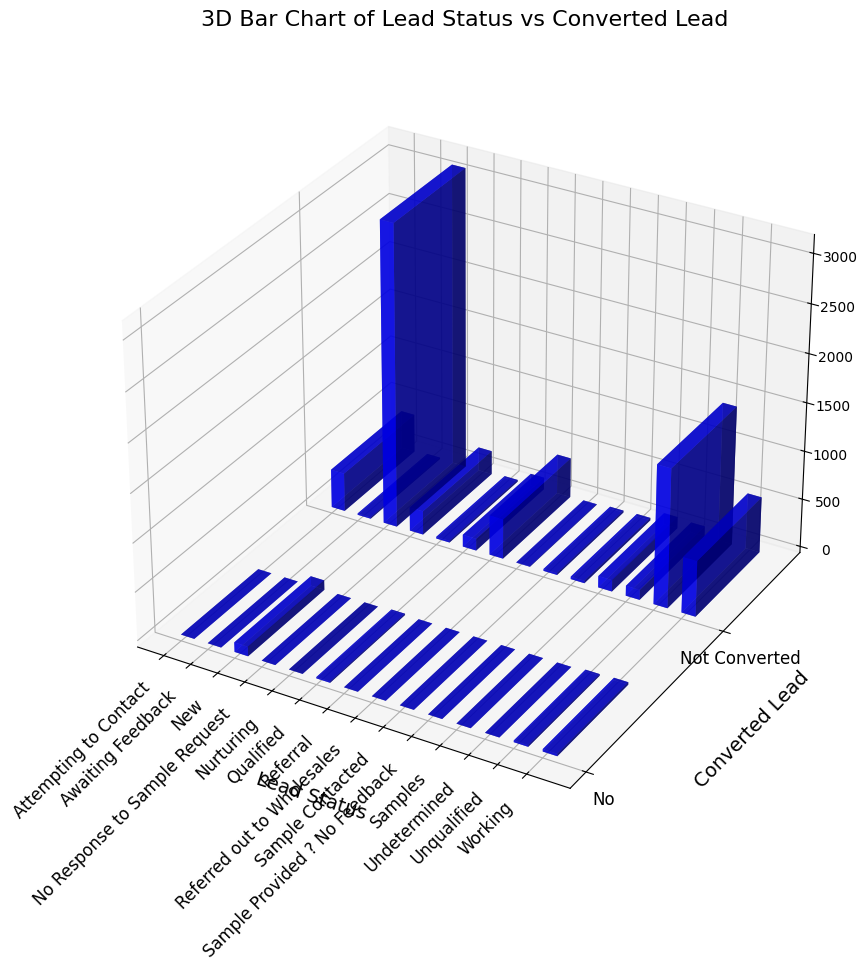

In [53]:
# Assuming Leads_df is your DataFrame
# Pivot table to count the number of leads for each combination of LeadStatus and ConvertedLead
lead_status_converted = Leads_df.pivot_table(index='LeadStatus', columns='ConvertedLead', aggfunc='size', fill_value=0)

# Extracting unique labels for LeadStatus and ConvertedLead
x_labels = lead_status_converted.index  # LeadStatus
y_labels = lead_status_converted.columns  # ConvertedLead

# Creating meshgrid for LeadStatus (x-axis) and ConvertedLead (y-axis)
x_pos, y_pos = np.meshgrid(np.arange(len(x_labels)), np.arange(len(y_labels)))

# Flattening the grid for 3D bar chart
x_pos = x_pos.flatten()
y_pos = y_pos.flatten()

# Corresponding values (z-axis) from the pivot table
z_values = lead_status_converted.T.values.flatten()

# Base positions for the bars (start at z=0)
z_pos = np.zeros_like(x_pos)

# The height of each bar is based on the count of leads
dz = z_values

# Create the 3D plot
fig = plt.figure(figsize=(16, 10))
ax = fig.add_subplot(111, projection='3d')

# Create 3D bars
dx = dy = 0.5  # Width and depth of bars
ax.bar3d(x_pos, y_pos, z_pos, dx, dy, dz, color='b', alpha=0.7)

# Set the labels and title
ax.set_xlabel('Lead Status', fontsize=14, labelpad=20)
ax.set_ylabel('Converted Lead', fontsize=14, labelpad=20)
ax.set_zlabel('Count of Leads', fontsize=14, labelpad=20)

# Set tick labels
ax.set_xticks(np.arange(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=12)
ax.set_yticks(np.arange(len(y_labels)))
ax.set_yticklabels(y_labels, fontsize=12)

# Set title
ax.set_title('3D Bar Chart of Lead Status vs Converted Lead', fontsize=16, pad=30)

plt.tight_layout()
plt.show()


In [ ]:
# Pivot table to count the number of leads for each combination of LeadStatus and ConvertedLead
lead_status_converted = Leads_df.pivot_table(index='LeadStatus', columns='ConvertedLead', aggfunc='size', fill_value=0)

# Creating the heatmap with orange to red color map
plt.figure(figsize=(12, 8))
sns.heatmap(lead_status_converted, annot=True, cmap='OrRd', linewidths=0.5, fmt='d')

# Adding labels and title
plt.title('Heatmap of Lead Status vs Converted Lead (All Company)', fontsize=16)
plt.xlabel('Converted Lead', fontsize=14)
plt.ylabel('Lead Status', fontsize=14)

plt.tight_layout()
plt.show()


In [71]:
# Assuming Leads_df is your DataFrame
# Unique LeadStatus and ConvertedLead labels
lead_status_labels = Leads_df['LeadStatus'].unique().tolist()
converted_lead_labels = Leads_df['ConvertedLead'].unique().tolist()

# Combine both LeadStatus and ConvertedLead to create one list of all labels
all_labels = lead_status_labels + converted_lead_labels

# Mapping labels to their indices
label_indices = {label: i for i, label in enumerate(all_labels)}

# Create 'source', 'target', and 'value' arrays for the Sankey diagram
sankey_source = []
sankey_target = []
sankey_values = []

# Group by LeadStatus and ConvertedLead to count the transitions
transition_counts = Leads_df.groupby(['LeadStatus', 'ConvertedLead']).size().reset_index(name='Count')

# Populate the source, target, and values
for _, row in transition_counts.iterrows():
    sankey_source.append(label_indices[row['LeadStatus']])  # Map LeadStatus to index
    sankey_target.append(label_indices[row['ConvertedLead']])  # Map ConvertedLead to index
    sankey_values.append(row['Count'])  # Use the count of transitions

# Create Sankey diagram
fig = go.Figure(go.Sankey(
    node=dict(
        pad=95,
        thickness=60,
        line=dict(color="black", width=2.5),
        label=all_labels
    ),
    link=dict(
        source=sankey_source,  # Indices of source nodes
        target=sankey_target,  # Indices of target nodes
        value=sankey_values    # Values represent the count of transitions
    )
))

# Update layout
fig.update_layout(title_text="Sankey Diagram of Lead Status to Converted Lead", font_size=10)
fig.show()


In [ ]:
# change x and y values in above code
# Ensure blanks and nulls are included in the count
rating_lead_owner = Leads_df.pivot_table(index='LeadOwner', columns='Rating', aggfunc='size', fill_value=0)

# Sort the pivot table by the total number of leads per LeadOwner in descending order
rating_lead_owner = rating_lead_owner.loc[rating_lead_owner.sum(axis=1).sort_values(ascending=True).index]

# Creating a horizontal stacked bar chart
plt.figure(figsize=(12, 14))
rating_lead_owner.plot(kind='barh', stacked=True, figsize=(18, 8))

# Adding labels and title
plt.xlabel('Number of Leads')
plt.ylabel('Lead Owner')
plt.title('Number of Unconverted Leads by Lead Owner and Rating (All Company)')

plt.legend(title='Rating', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adding the total lead count at the end of each bar
for index, value in enumerate(rating_lead_owner.sum(axis=1)):
    plt.text(value, index, str(value), va='center')

plt.tight_layout()  # To ensure the labels and title fit nicely

plt.show()